In [7]:
%pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sys
from pathlib import Path

# Path setup
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import DB_URL

# Configuracion de graficos
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

# Conectar a PostgreSQL
engine = create_engine(DB_URL, pool_pre_ping=True)

# Cargar datos principales
df = pd.read_sql("""
    SELECT 
        mc.datetime,
        mc.cmg_usd_mwh,
        g.gen_solar_mw,
        g.gen_wind_mw,
        g.gen_hydro_reservoir_mw,
        g.gen_gas_mw,
        g.gen_coal_mw,
        g.gen_total_mw,
        w.temp_max_c
    FROM marginal_costs mc
    LEFT JOIN generation_by_tech g ON g.datetime = mc.datetime
    LEFT JOIN weather w ON w.date = mc.datetime::date AND w.region = 'Santiago'
    WHERE mc.barra = 'Quillota 220kV'
    ORDER BY mc.datetime
""", engine, parse_dates=['datetime'])

df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.set_index('datetime')

print(f"Shape: {df.shape}")
print(f"Rango: {df.index.min()} → {df.index.max()}")
print(f"\nPrimeras columnas:\n{df.dtypes}")

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\ferna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Shape: (48523, 8)
Rango: 2019-01-01 03:00:00+00:00 → 2024-04-07 02:00:00+00:00

Primeras columnas:
cmg_usd_mwh               float64
gen_solar_mw              float64
gen_wind_mw               float64
gen_hydro_reservoir_mw    float64
gen_gas_mw                float64
gen_coal_mw               float64
gen_total_mw              float64
temp_max_c                float64
dtype: object


=== CMG USD/MWh ===
count    48523.00
mean        69.35
std         57.16
min          0.00
25%         34.17
50%         55.64
75%         91.72
max        431.77
Name: cmg_usd_mwh, dtype: float64

Valores cero: 5741
Valores < 5:  6016
Valores > 100: 10494
Valores > 200: 1304


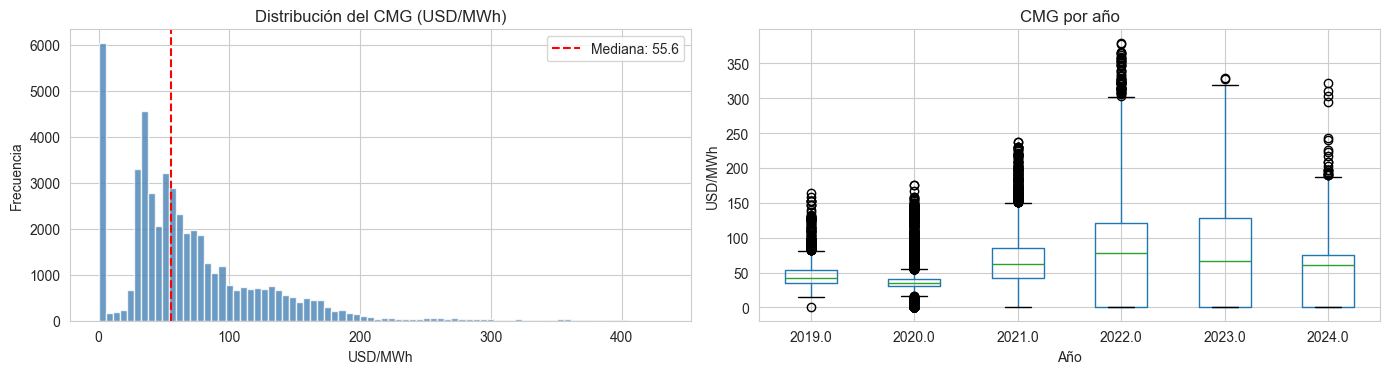

In [8]:
# ── Estadísticas descriptivas del CMG ─────────────────────────────────────
print("=== CMG USD/MWh ===")
print(df['cmg_usd_mwh'].describe().round(2))
print(f"\nValores cero: {(df['cmg_usd_mwh'] == 0).sum()}")
print(f"Valores < 5:  {(df['cmg_usd_mwh'] < 5).sum()}")
print(f"Valores > 100: {(df['cmg_usd_mwh'] > 100).sum()}")
print(f"Valores > 200: {(df['cmg_usd_mwh'] > 200).sum()}")

# ── Distribución del CMG ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma
axes[0].hist(df['cmg_usd_mwh'].dropna(), bins=80, 
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución del CMG (USD/MWh)')
axes[0].set_xlabel('USD/MWh')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['cmg_usd_mwh'].median(), color='red', 
                linestyle='--', label=f"Mediana: {df['cmg_usd_mwh'].median():.1f}")
axes[0].legend()

# Boxplot por año
df['anio'] = df.index.year
df.boxplot(column='cmg_usd_mwh', by='anio', ax=axes[1])
axes[1].set_title('CMG por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('USD/MWh')
plt.suptitle('')

plt.tight_layout()
plt.show()

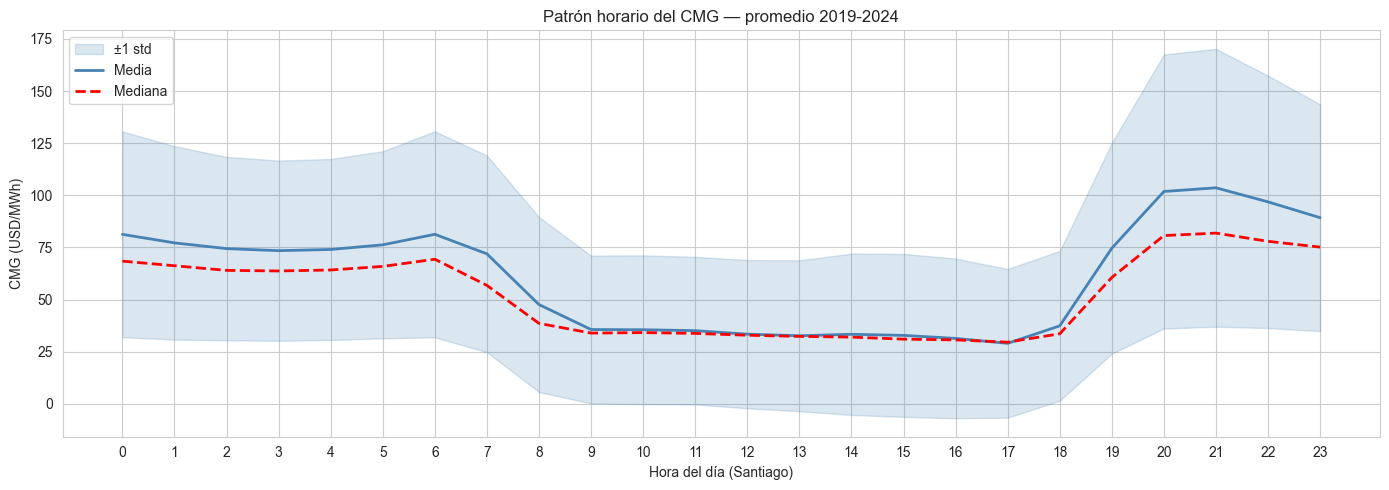


Hora con CMG más bajo: 17.0 (29.0 USD/MWh)
Hora con CMG más alto: 21.0 (103.6 USD/MWh)


In [9]:
# ── Patrón horario del CMG ─────────────────────────────────────────────────
df['hora'] = df.index.tz_convert('America/Santiago').hour

hourly = df.groupby('hora')['cmg_usd_mwh'].agg(['mean', 'median', 'std'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(hourly.index, 
                hourly['mean'] - hourly['std'],
                hourly['mean'] + hourly['std'],
                alpha=0.2, color='steelblue', label='±1 std')
ax.plot(hourly.index, hourly['mean'], 
        color='steelblue', linewidth=2, label='Media')
ax.plot(hourly.index, hourly['median'], 
        color='red', linewidth=2, linestyle='--', label='Mediana')
ax.set_title('Patrón horario del CMG — promedio 2019-2024')
ax.set_xlabel('Hora del día (Santiago)')
ax.set_ylabel('CMG (USD/MWh)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

print("\nHora con CMG más bajo:", hourly['mean'].idxmin(), 
      f"({hourly['mean'].min():.1f} USD/MWh)")
print("Hora con CMG más alto:", hourly['mean'].idxmax(), 
      f"({hourly['mean'].max():.1f} USD/MWh)")

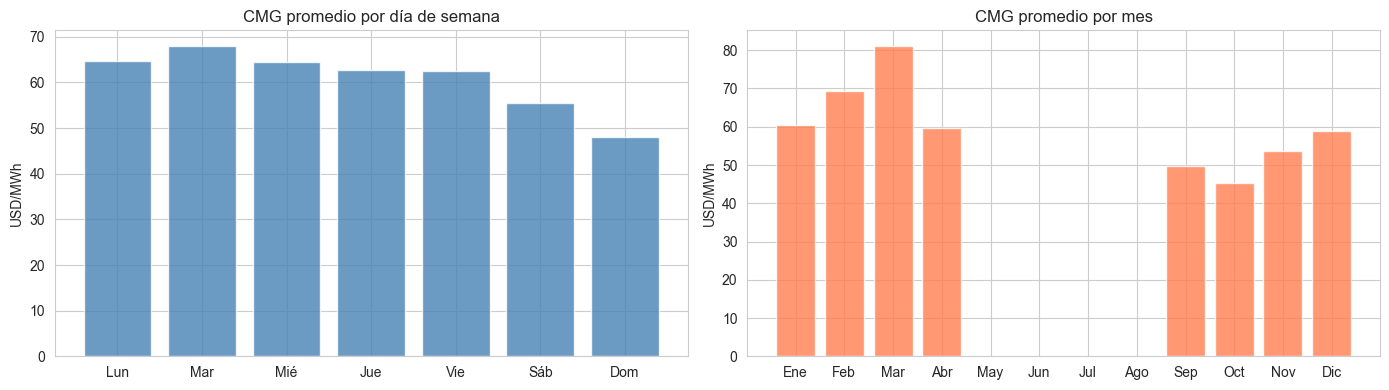

Día más barato: Dom (48.0 USD/MWh)
Día más caro:   Mar (68.0 USD/MWh)

Mes más barato: Oct (45.4 USD/MWh)
Mes más caro:   Mar (81.1 USD/MWh)


In [11]:
# ── Patrón semanal ─────────────────────────────────────────────────────────
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
df['dow'] = df.index.tz_convert('America/Santiago').dayofweek
weekly = df.groupby('dow')['cmg_usd_mwh'].mean()

# ── Patrón mensual ─────────────────────────────────────────────────────────
df['mes'] = df.index.tz_convert('America/Santiago').month
monthly = df.groupby('mes')['cmg_usd_mwh'].mean().reindex(range(1, 13))

meses = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(7), weekly.values, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dias)
axes[0].set_title('CMG promedio por día de semana')
axes[0].set_ylabel('USD/MWh')

axes[1].bar(range(1, 13), monthly.values, color='coral', alpha=0.8)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses)
axes[1].set_title('CMG promedio por mes')
axes[1].set_ylabel('USD/MWh')

plt.tight_layout()
plt.show()

print("Día más barato:", dias[int(weekly.idxmin())],
      f"({weekly.min():.1f} USD/MWh)")
print("Día más caro:  ", dias[int(weekly.idxmax())],
      f"({weekly.max():.1f} USD/MWh)")

mes_min = int(monthly.idxmin())
mes_max = int(monthly.idxmax())
print(f"\nMes más barato: {meses[mes_min-1]} ({monthly.min():.1f} USD/MWh)")
print(f"Mes más caro:   {meses[mes_max-1]} ({monthly.max():.1f} USD/MWh)")

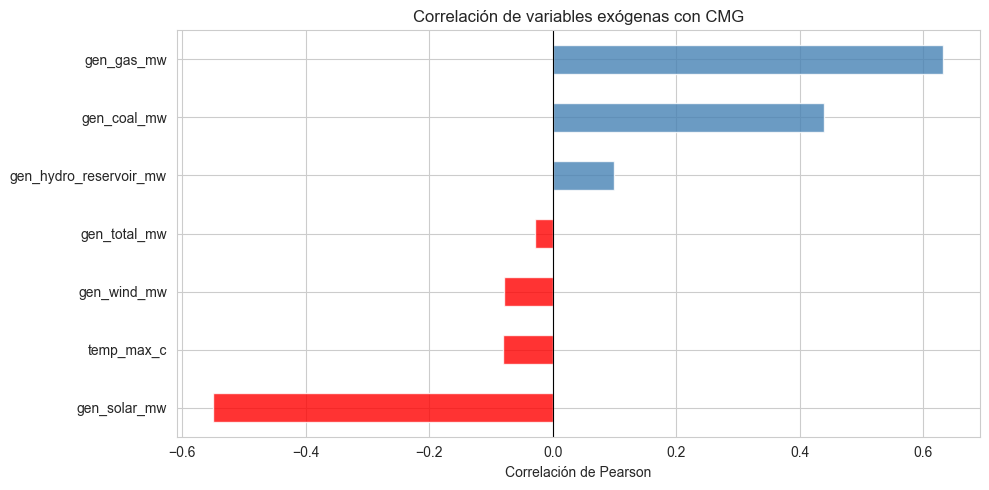

Correlaciones con CMG:
  gen_solar_mw                        -0.550  ↓ baja CMG
  temp_max_c                          -0.081  ↓ baja CMG
  gen_wind_mw                         -0.079  ↓ baja CMG
  gen_total_mw                        -0.029  ↓ baja CMG
  gen_hydro_reservoir_mw              +0.099  ↑ sube CMG
  gen_coal_mw                         +0.439  ↑ sube CMG
  gen_gas_mw                          +0.633  ↑ sube CMG


In [12]:
# ── Correlaciones con el CMG ───────────────────────────────────────────────
vars_exogenas = [
    'gen_solar_mw', 'gen_wind_mw', 'gen_hydro_reservoir_mw',
    'gen_gas_mw', 'gen_coal_mw', 'gen_total_mw', 'temp_max_c'
]

correlaciones = df[['cmg_usd_mwh'] + vars_exogenas].corr()['cmg_usd_mwh'].drop('cmg_usd_mwh').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['red' if v < 0 else 'steelblue' for v in correlaciones.values]
correlaciones.plot(kind='barh', ax=ax, color=colores, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de variables exógenas con CMG')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print("Correlaciones con CMG:")
for var, corr in correlaciones.items():
    direccion = "↑ sube CMG" if corr > 0 else "↓ baja CMG"
    print(f"  {var:35s} {corr:+.3f}  {direccion}")

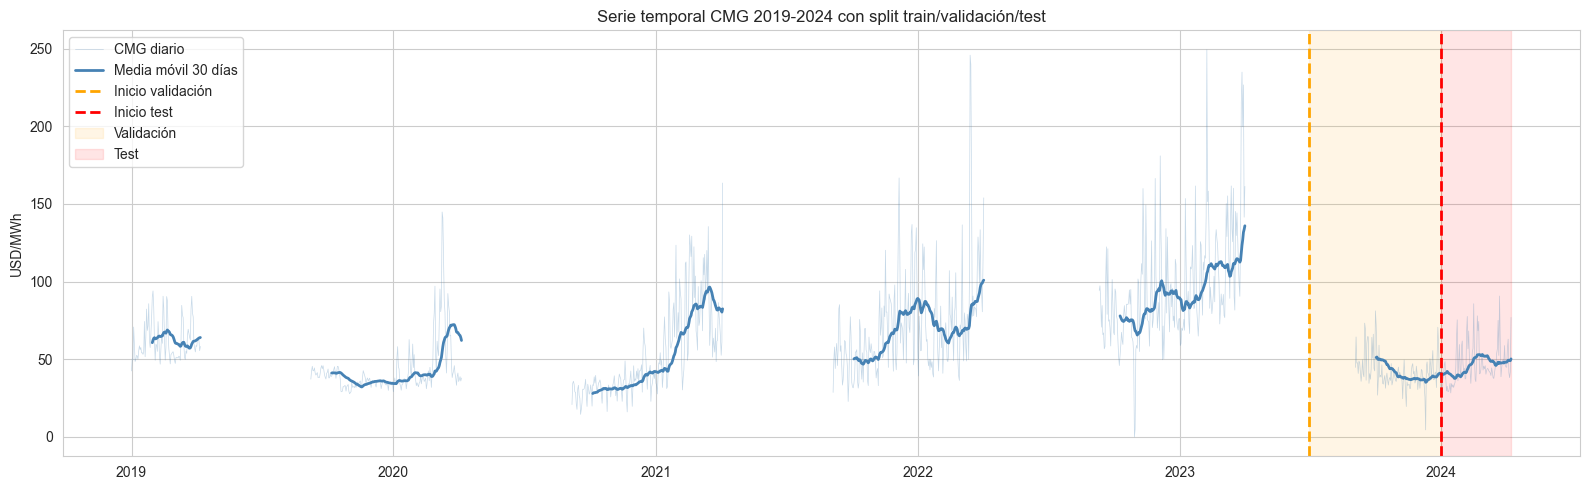

Train:      22,292 horas | media 64.7 | std 53.1
Validación: 2,876 horas | media 42.0 | std 44.6
Test:       2,331 horas | media 46.9 | std 43.9


In [13]:
# ── Serie temporal completa con split ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

# Serie completa con media móvil de 7 días
cmg_diario = df['cmg_usd_mwh'].resample('D').mean()
cmg_rolling = cmg_diario.rolling(30).mean()

ax.plot(cmg_diario.index, cmg_diario.values, 
        alpha=0.3, color='steelblue', linewidth=0.5, label='CMG diario')
ax.plot(cmg_rolling.index, cmg_rolling.values,
        color='steelblue', linewidth=2, label='Media móvil 30 días')

# Líneas del split
ax.axvline(pd.Timestamp('2023-07-01', tz='UTC'), 
           color='orange', linewidth=2, linestyle='--', label='Inicio validación')
ax.axvline(pd.Timestamp('2024-01-01', tz='UTC'),
           color='red', linewidth=2, linestyle='--', label='Inicio test')

# Sombrear zonas
ax.axvspan(pd.Timestamp('2023-07-01', tz='UTC'),
           pd.Timestamp('2024-01-01', tz='UTC'),
           alpha=0.1, color='orange', label='Validación')
ax.axvspan(pd.Timestamp('2024-01-01', tz='UTC'),
           cmg_diario.index.max(),
           alpha=0.1, color='red', label='Test')

ax.set_title('Serie temporal CMG 2019-2024 con split train/validación/test')
ax.set_ylabel('USD/MWh')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Estadísticas por split
train = df[df.index < '2023-07-01']['cmg_usd_mwh']
val   = df[(df.index >= '2023-07-01') & (df.index < '2024-01-01')]['cmg_usd_mwh']
test  = df[df.index >= '2024-01-01']['cmg_usd_mwh']

print(f"Train:      {len(train):,} horas | media {train.mean():.1f} | std {train.std():.1f}")
print(f"Validación: {len(val):,} horas | media {val.mean():.1f} | std {val.std():.1f}")
print(f"Test:       {len(test):,} horas | media {test.mean():.1f} | std {test.std():.1f}")